# compare

Load the three DRL runs, validate their metadata, evaluate eight schemes on the same test window, and export the comparison table plus the requested comparison figures.

The compare figures below now use a single shared price/prediction pair, feeder-total net load only, and a combined battery-power/SoC panel for each scheme.


In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "configs").exists():
    project_root = project_root.parent
if not (project_root / "configs").exists():
    raise RuntimeError("Could not locate the project root from the notebook working directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from IPython.display import display

import pandas as pd

from configs import compose_experiment_config
from scripts.utils.experiment_notebook_utils import resolve_madrl_model_root
from scripts.utils.grid_notebook_workflow import (
    apply_notebook_experiment_settings,
    build_compare_economic_table,
    build_compare_safety_table,
    build_compare_warning_banner,
    collect_global_full_horizon_rollout,
    collect_madrl_rollout,
    collect_mpc_rollout,
    compare_rollout_metrics,
    plot_battery_power_and_soc_comparison,
    plot_net_load_comparison,
    plot_power_balance_comparison,
    plot_price_prediction_comparison,
    plot_voltage_profile_comparison,
    validate_compare_model_bundles,
)
from scripts.utils.dual_distributed_notebook_helpers import collect_dual_two_pass_rollout
from scripts.utils.madrl_shared_data import ensure_madrl_shared_data
from scripts.utils.misocp_notebook_helpers import (
    replay_misocp_plan_package,
    resolve_latest_compatible_misocp_plan_package_dir,
)
from scripts.utils.project_paths import project_root


In [2]:
PROJECT_ROOT = project_root()
DATA_DIR = PROJECT_ROOT / "data"
CHECKPOINT_ROOT = None
PREDICTION_MODE = "normal"  # Used for MADRL checkpoint/reference bundle resolution; MPC/Dual still run both perfect and normal explicitly.

W_SOC_PEN = 10.0
EVAL_W_VOLTAGE_PEN = 10.0
EVAL_W_LINE_PEN = 10.0
EVAL_W_TRAFO_PEN = 10.0
USE_CACHED_MISOCP_PLAN = True
MISOCP_PLAN_INPUT_DIR = None
COMPARE_TEST_START = "2020-06-01"
COMPARE_TEST_END = "2020-06-30"

DRL_RUN_SPECS = {
    "MADRL + No Safety": {"algorithm": "MATD3", "experiment_name": "train_base", "model_root": None},
    "MADRL + Safety Penalty": {"algorithm": "MATD3", "experiment_name": "train_base_safe", "model_root": None},
    "MADRL + Safety Projection": {
        "algorithm": "MATD3_SAFE_POC",
        "experiment_name": "train_projection_safe",
        "model_root": None,
    },
}

EXPORT_DIR = PROJECT_ROOT / "artifacts" / "compare"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
resolved_model_roots = {}
for label, spec in DRL_RUN_SPECS.items():
    resolved_model_roots[label] = resolve_madrl_model_root(
        algorithm=spec["algorithm"],
        prediction_mode=PREDICTION_MODE,
        experiment_name=spec["experiment_name"],
        model_root=spec.get("model_root"),
        root=PROJECT_ROOT,
        checkpoint_root=CHECKPOINT_ROOT,
    )

bundles = validate_compare_model_bundles(resolved_model_roots)
display(
    pd.DataFrame(
        {
            "scheme": list(resolved_model_roots.keys()),
            "model_root": [str(path) for path in resolved_model_roots.values()],
        }
    )
)


,scheme,model_root
0,MADRL + No Safety,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...
1,MADRL + Safety Penalty,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...
2,MADRL + Safety Projection,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...


In [ ]:
reference_bundle = bundles["MADRL + No Safety"]
reference_experiment = reference_bundle["experiment_controls"]
reference_data = reference_bundle["data_controls"]
reference_battery = reference_bundle["battery_controls"]
reference_train = reference_bundle["train_controls"]

forecast_controls = dict(reference_experiment.get("forecast_controls") or {})
if forecast_controls:
    forecast_controls["auto_train_missing"] = False

cfg = compose_experiment_config(
    profile=reference_train.get("profile", "base"),
    algorithm="MATD3",
    model_family=reference_train.get("model_family", "mlp"),
    data_dir=DATA_DIR,
    device=reference_experiment.get("device_request"),
    runtime_mode=reference_experiment.get("runtime_mode", "performance"),
    seed=int(reference_experiment.get("seed", 0)),
    require_cuda=reference_experiment.get("require_cuda"),
)
apply_notebook_experiment_settings(
    cfg,
    prediction_mode=reference_data["prediction_mode"],
    test_start_date=COMPARE_TEST_START or reference_data.get("test_start_date"),
    test_end_date=COMPARE_TEST_END or reference_data.get("test_end_date"),
    agent_profiles=reference_data["agent_profiles"],
    agent_bus_ids=reference_data.get("agent_bus_ids"),
    load_scale=reference_data.get("load_scale"),
    pv_scale=reference_data.get("pv_scale"),
    battery_controls=reference_battery,
    forecast_controls=forecast_controls,
    future_horizon=reference_data.get("future_horizon"),
    train_year=reference_data.get("train_year"),
    test_year=reference_data.get("test_year"),
)
cfg.reward.w_soc_pen = W_SOC_PEN
cfg.reward.w_voltage_pen = EVAL_W_VOLTAGE_PEN
cfg.reward.w_line_pen = EVAL_W_LINE_PEN
cfg.reward.w_trafo_pen = EVAL_W_TRAFO_PEN

shared_data_result = ensure_madrl_shared_data(cfg)
cfg.runtime.shared_data_dir = str(shared_data_result.shared_data_dir)
cfg.runtime.shared_data_signature = str(shared_data_result.signature_hash)
if MISOCP_PLAN_INPUT_DIR is None:
    misocp_plan_tag = f"{cfg.data.test_start_date}_{cfg.data.test_end_date}_agents{cfg.env.num_agents}"
    misocp_plan_prefix = PROJECT_ROOT / "artifacts" / "misocp_cached_plan" / misocp_plan_tag
    MISOCP_PLAN_INPUT_DIR = resolve_latest_compatible_misocp_plan_package_dir(misocp_plan_prefix)
display(
    {
        "test_start_date": cfg.data.test_start_date,
        "test_end_date": cfg.data.test_end_date,
        "use_cached_misocp_plan": USE_CACHED_MISOCP_PLAN,
        "misocp_plan_input_dir": str(MISOCP_PLAN_INPUT_DIR),
        "import_price_adder_eur_per_kwh": float(cfg.reward.import_price_adder_eur_per_kwh),
        "shared_data_dir": cfg.runtime.shared_data_dir,
        "shared_data_signature": cfg.runtime.shared_data_signature,
        "shared_data_reused": bool(shared_data_result.reused),
    }
)


{'test_start_date': '2020-06-01',
 'test_end_date': '2020-06-05',
 'use_cached_misocp_plan': True,
 'misocp_plan_input_dir': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\misocp_cached_plan\\2020-06-01_2020-06-30_agents5_7ad699',
 'import_price_adder_eur_per_kwh': 0.2,
 'shared_data_dir': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\training\\shared_data\\mainline\\1f4a3d35dbf1eac7',
 'shared_data_signature': '1f4a3d35dbf1eac7',
 'shared_data_reused': False}

In [ ]:
# Re-run this rollout collection cell after helper updates so compare figures use fresh step_df/meta fields.
print("Starting Global MISOCP cached replay...")
if USE_CACHED_MISOCP_PLAN:
    if not Path(MISOCP_PLAN_INPUT_DIR).exists():
        raise FileNotFoundError(
            f"Missing cached MISOCP plan package at {MISOCP_PLAN_INPUT_DIR}. "
            "Run MISOCP_global.ipynb first or point MISOCP_PLAN_INPUT_DIR to an existing package."
        )
    global_oracle_bundle = replay_misocp_plan_package(
        cfg,
        MISOCP_PLAN_INPUT_DIR,
    )
    global_oracle = global_oracle_bundle["rollout"]
else:
    global_oracle = collect_global_full_horizon_rollout(
        cfg,
        label="Global MISOCP (single_window)",
    )
print("Done:", global_oracle.meta.get("controller", "Global MISOCP"))
display(pd.Series({
    "controller": global_oracle.meta.get("controller", "Global MISOCP"),
    "solve_mode": global_oracle.meta.get("solve_mode", "unknown"),
    "economics_scope": global_oracle.meta.get("economics_scope", "unknown"),
    "global_misocp_gap": global_oracle.meta.get("global_misocp_gap", global_oracle.meta.get("global_oracle_gap", float("nan"))),
    "is_near_optimal": global_oracle.meta.get("is_near_optimal", False),
    "loaded_from_cached_plan": global_oracle.meta.get("loaded_from_cached_plan", False),
}, name="global_misocp_meta"))
print("Starting Single-Agent MPC + Perfect Forecast...")
mpc_perfect = collect_mpc_rollout(
    cfg,
    prediction_mode="perfect",
    label="Single-Agent MPC + Perfect Forecast",
)
print("Done: Single-Agent MPC + Perfect Forecast")
print("Starting Single-Agent MPC + LSTM Forecast...")
mpc_lstm = collect_mpc_rollout(
    cfg,
    prediction_mode="normal",
    label="Single-Agent MPC + LSTM Forecast",
)
print("Done: Single-Agent MPC + LSTM Forecast")
print("Starting Dual MPC + Perfect Forecast...")
dual_perfect = collect_dual_two_pass_rollout(
    cfg,
    prediction_mode="perfect",
    label="Dual MPC + Perfect Forecast",
    show_progress=True,
)
print("Done: Dual MPC + Perfect Forecast")
print("Starting Dual MPC + LSTM Forecast...")
dual_lstm = collect_dual_two_pass_rollout(
    cfg,
    prediction_mode="normal",
    label="Dual MPC + LSTM Forecast",
    show_progress=True,
)
print("Done: Dual MPC + LSTM Forecast")
print("Starting MADRL + No Safety...")
madrl_base = collect_madrl_rollout(
    cfg,
    model_root=resolved_model_roots["MADRL + No Safety"],
    algorithm="MATD3",
    experiment_name="train_base",
    checkpoint_root=CHECKPOINT_ROOT,
    label="MADRL + No Safety",
)
print("Done: MADRL + No Safety")
print("Starting MADRL + Safety Penalty...")
madrl_safe = collect_madrl_rollout(
    cfg,
    model_root=resolved_model_roots["MADRL + Safety Penalty"],
    algorithm="MATD3",
    experiment_name="train_base_safe",
    checkpoint_root=CHECKPOINT_ROOT,
    label="MADRL + Safety Penalty",
)
print("Done: MADRL + Safety Penalty")
print("Starting MADRL + Safety Projection...")
madrl_projection = collect_madrl_rollout(
    cfg,
    model_root=resolved_model_roots["MADRL + Safety Projection"],
    algorithm="MATD3_SAFE_POC",
    experiment_name="train_projection_safe",
    checkpoint_root=CHECKPOINT_ROOT,
    label="MADRL + Safety Projection",
)
print("Done: MADRL + Safety Projection")

rollouts = [
    global_oracle,
    mpc_perfect,
    mpc_lstm,
    dual_perfect,
    dual_lstm,
    madrl_base,
    madrl_safe,
    madrl_projection,
]
print("Building comparison metrics...")
metrics_df = compare_rollout_metrics(*rollouts)
economic_table_df = build_compare_economic_table(metrics_df)
safety_table_df = build_compare_safety_table(metrics_df)
print("Done: metrics ready")
display(build_compare_warning_banner(*rollouts))
display(economic_table_df)
display(safety_table_df)


Starting Global MISOCP cached replay...


c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-

Done: Global MISOCP (single_window)


controller                 Global MISOCP (single_window)
solve_mode                                 single_window
economics_scope                               agent_only
global_misocp_gap                               0.977553
is_near_optimal                                    False
loaded_from_cached_plan                             True
Name: global_misocp_meta, dtype: object

Starting Single-Agent MPC + Perfect Forecast...
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2685996
Academic license 2685996 - for non-commercial use only - registered to 20___@mail.scut.edu.cn


Rendering price and prediction...


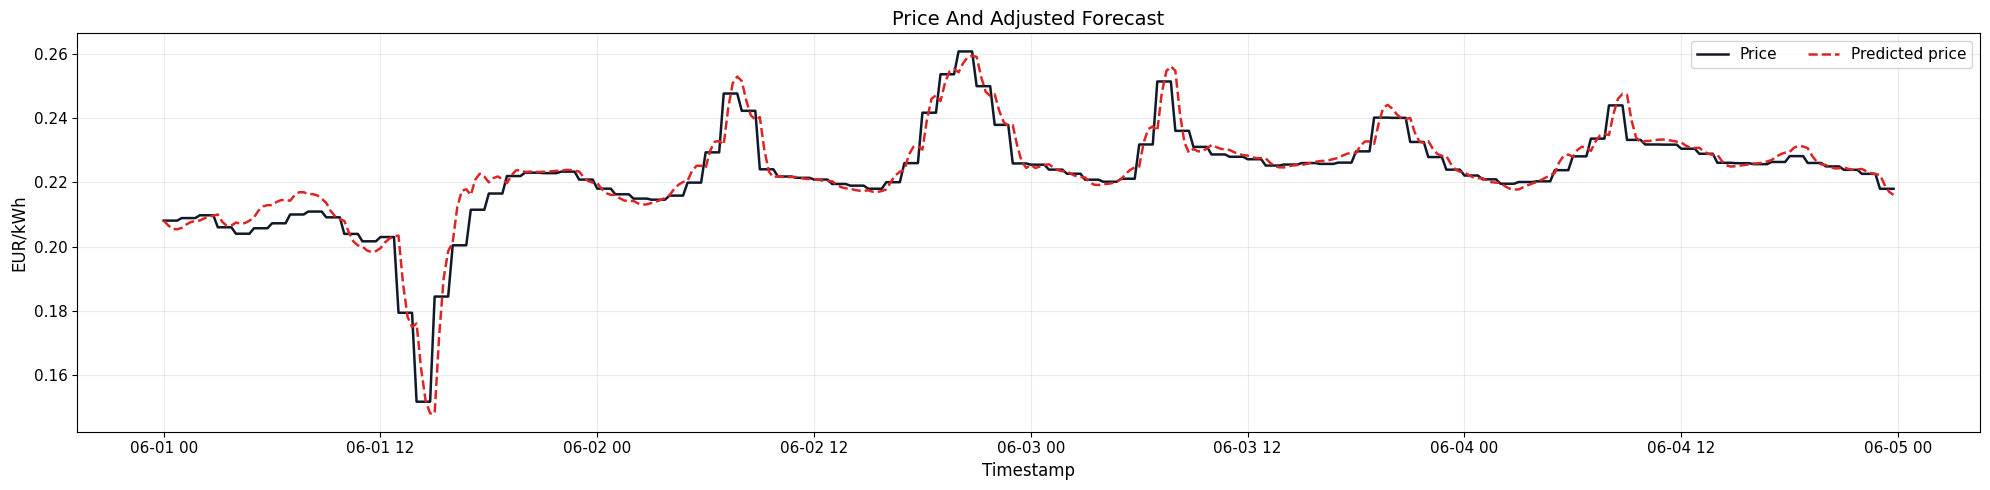

Done: price and prediction
Rendering power balance...


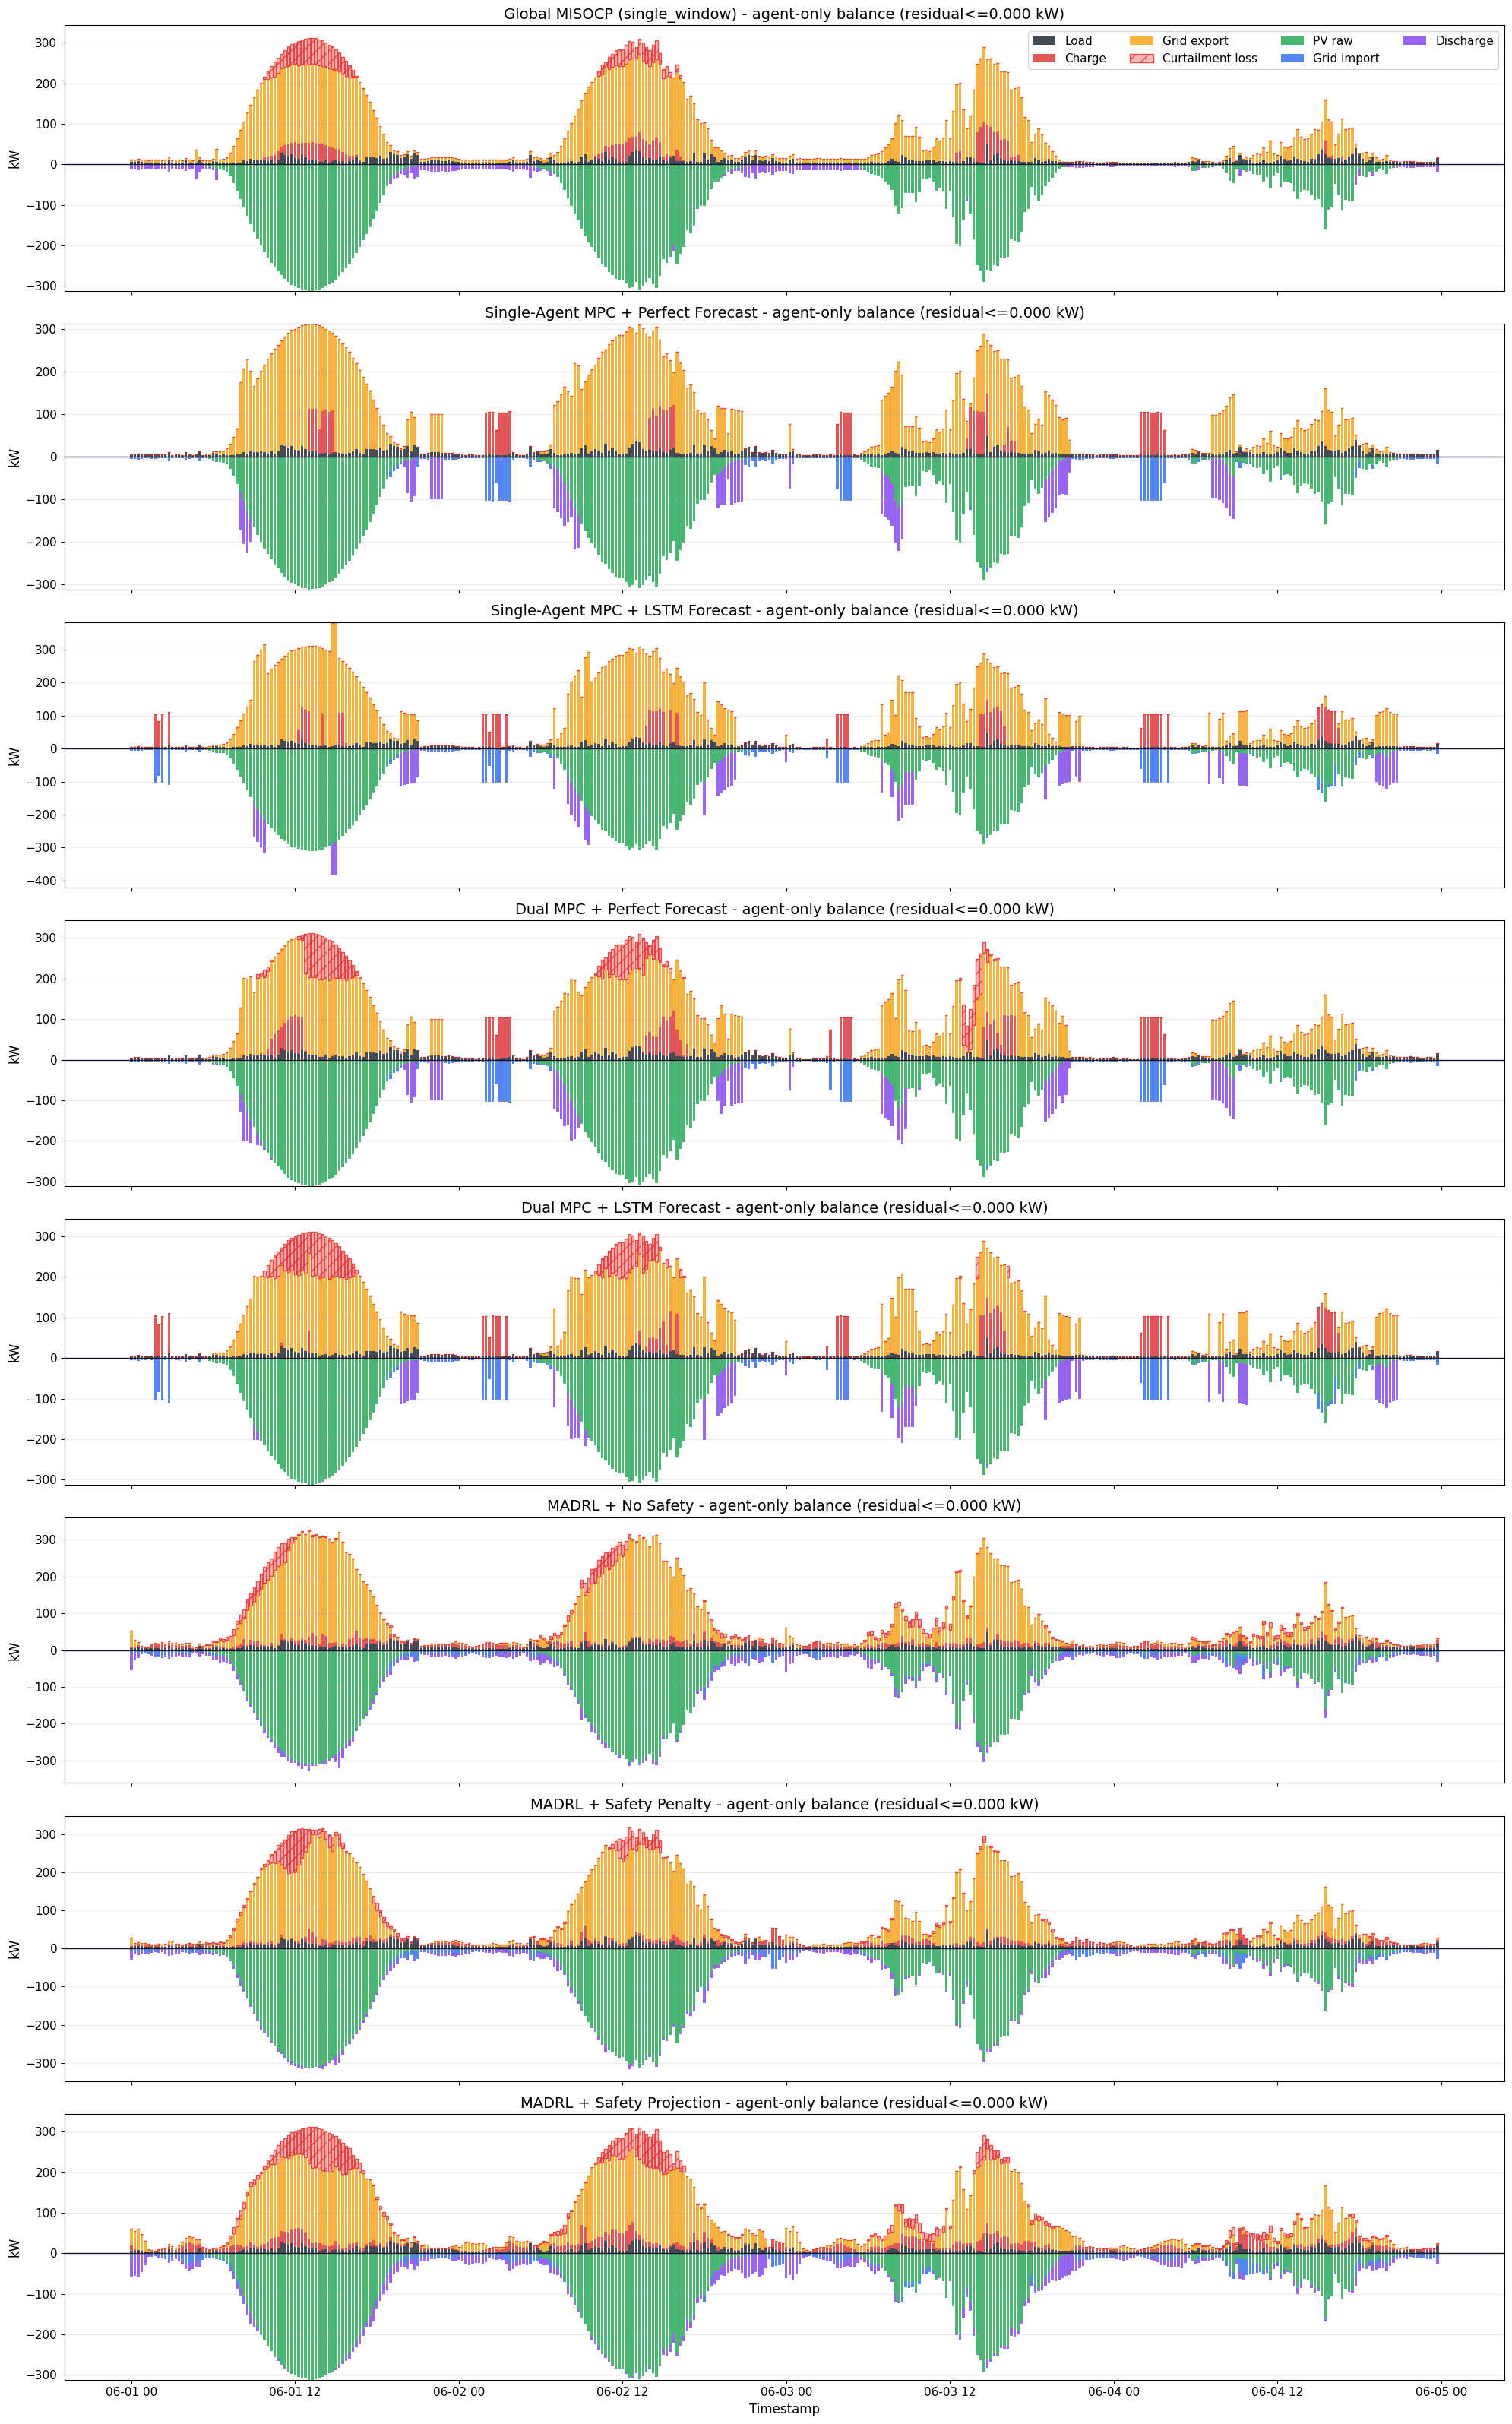

Done: power balance
Rendering voltage profile...


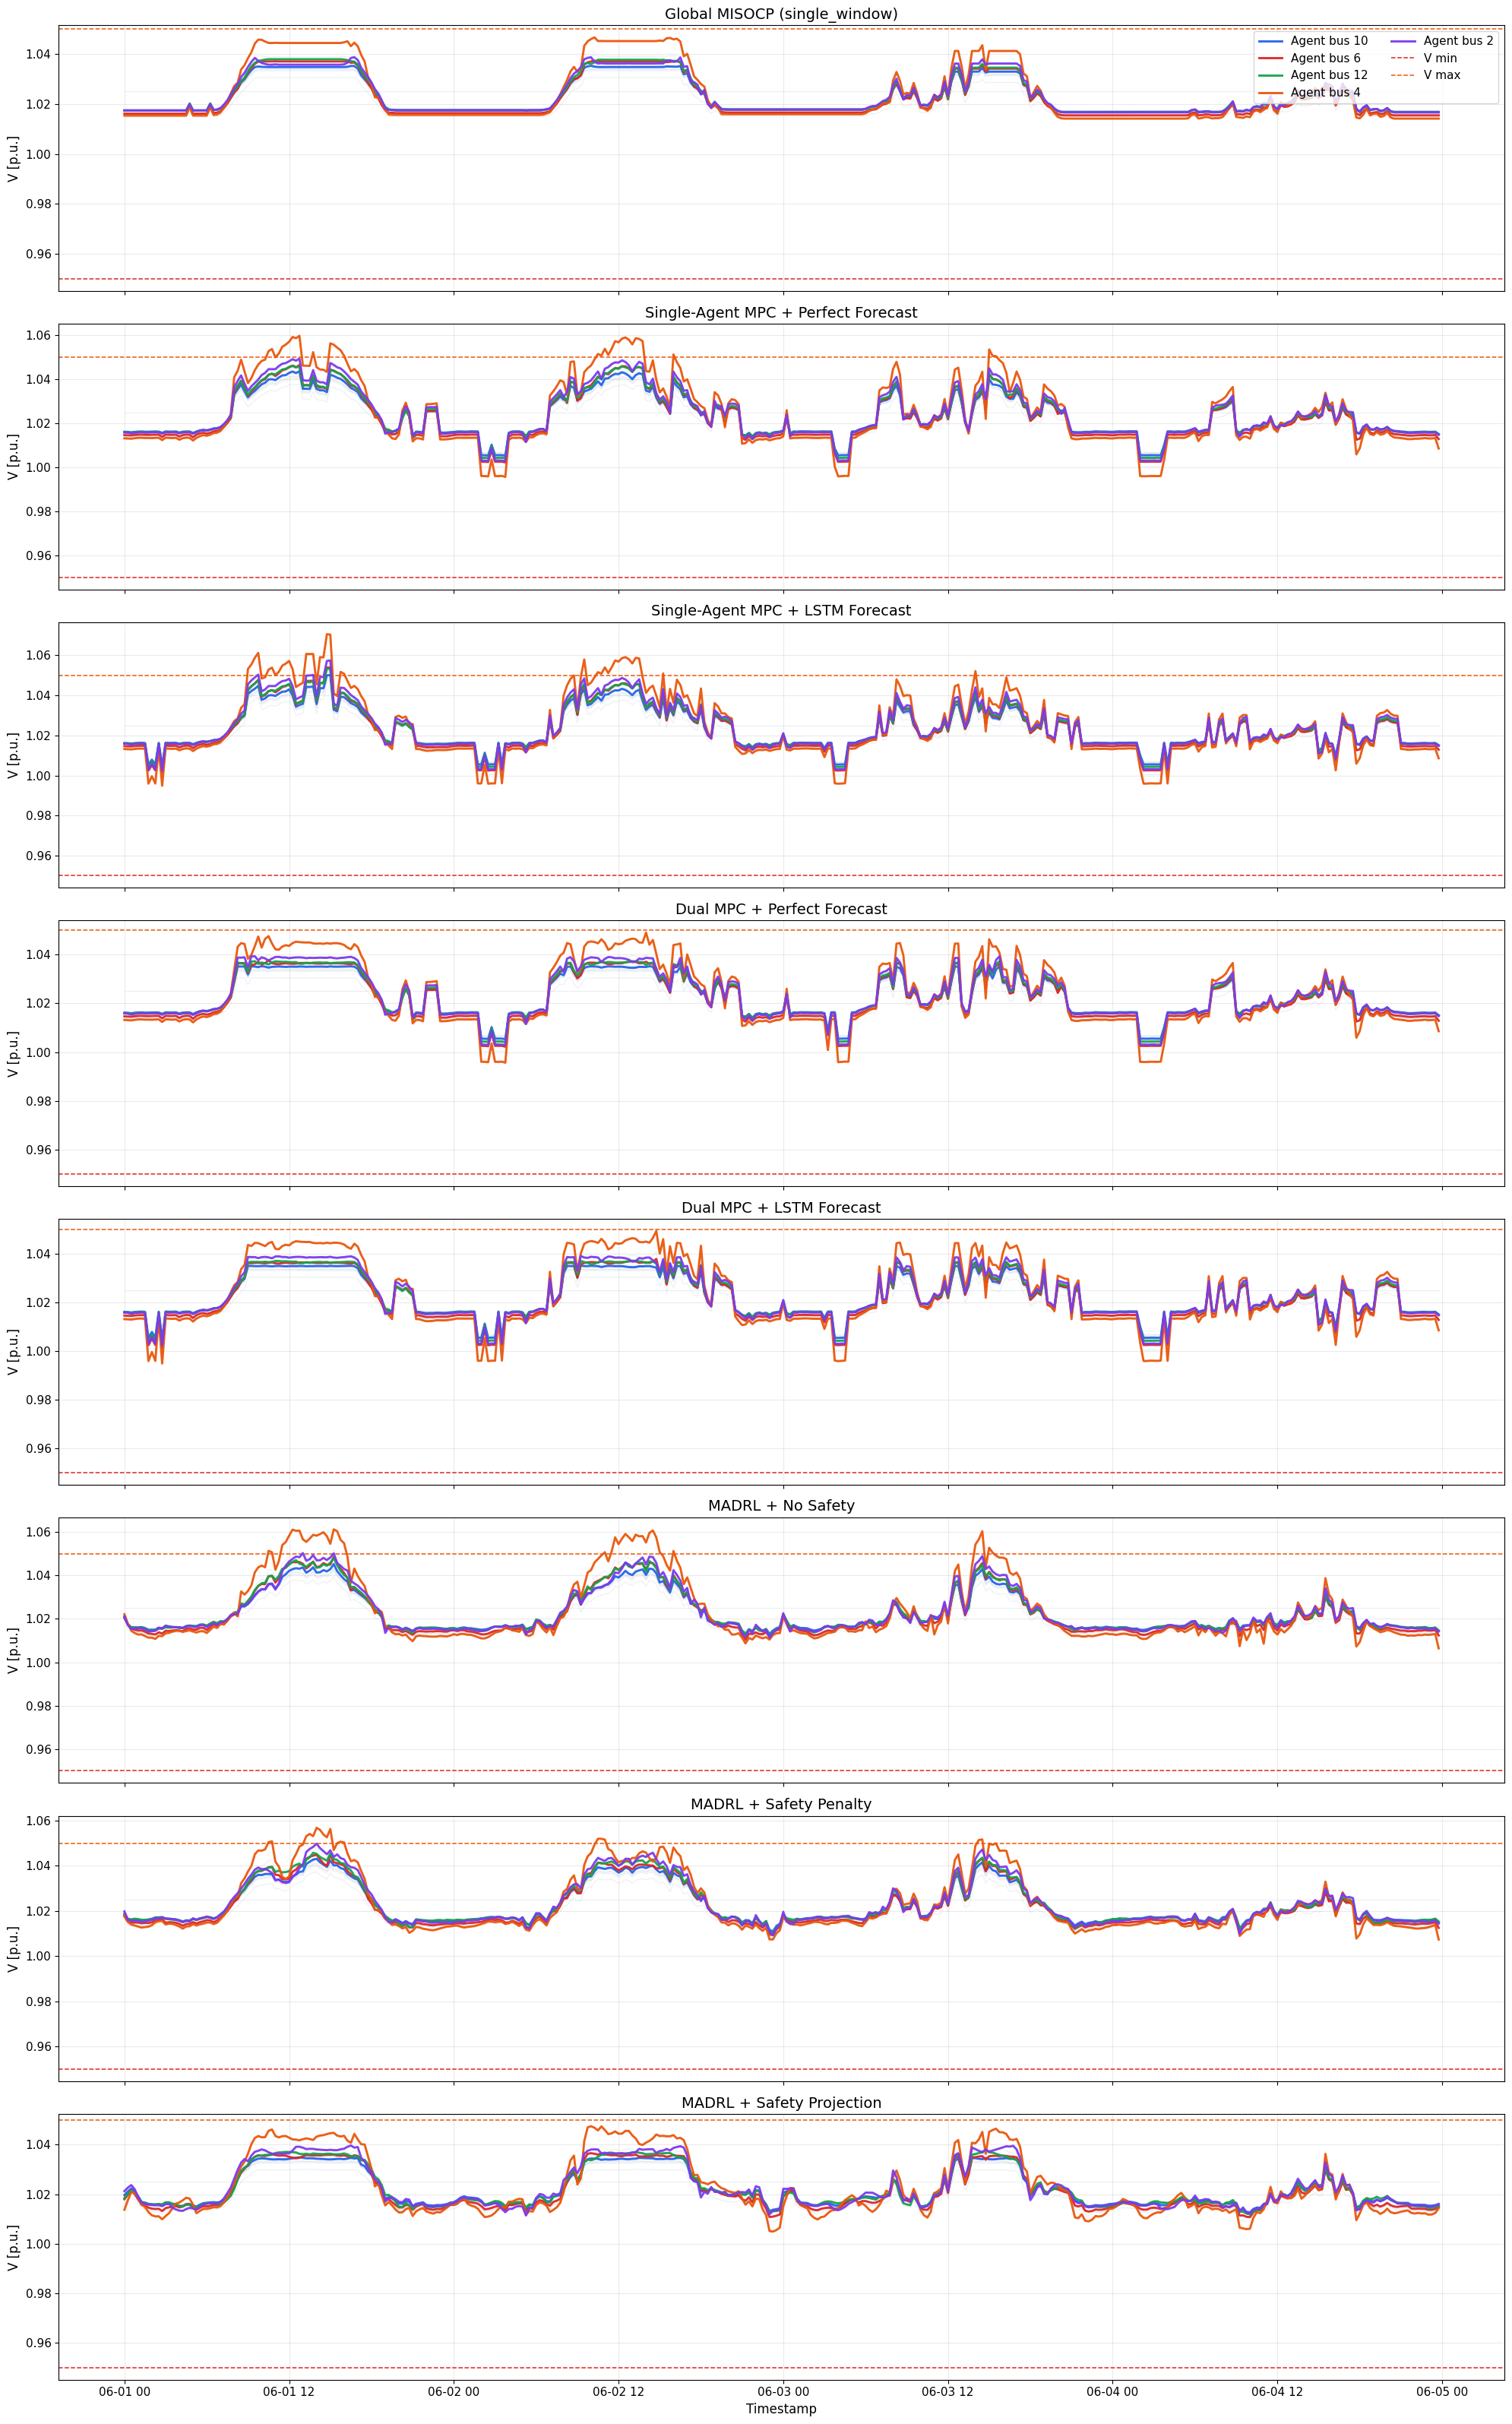

Done: voltage profile
Rendering net load...


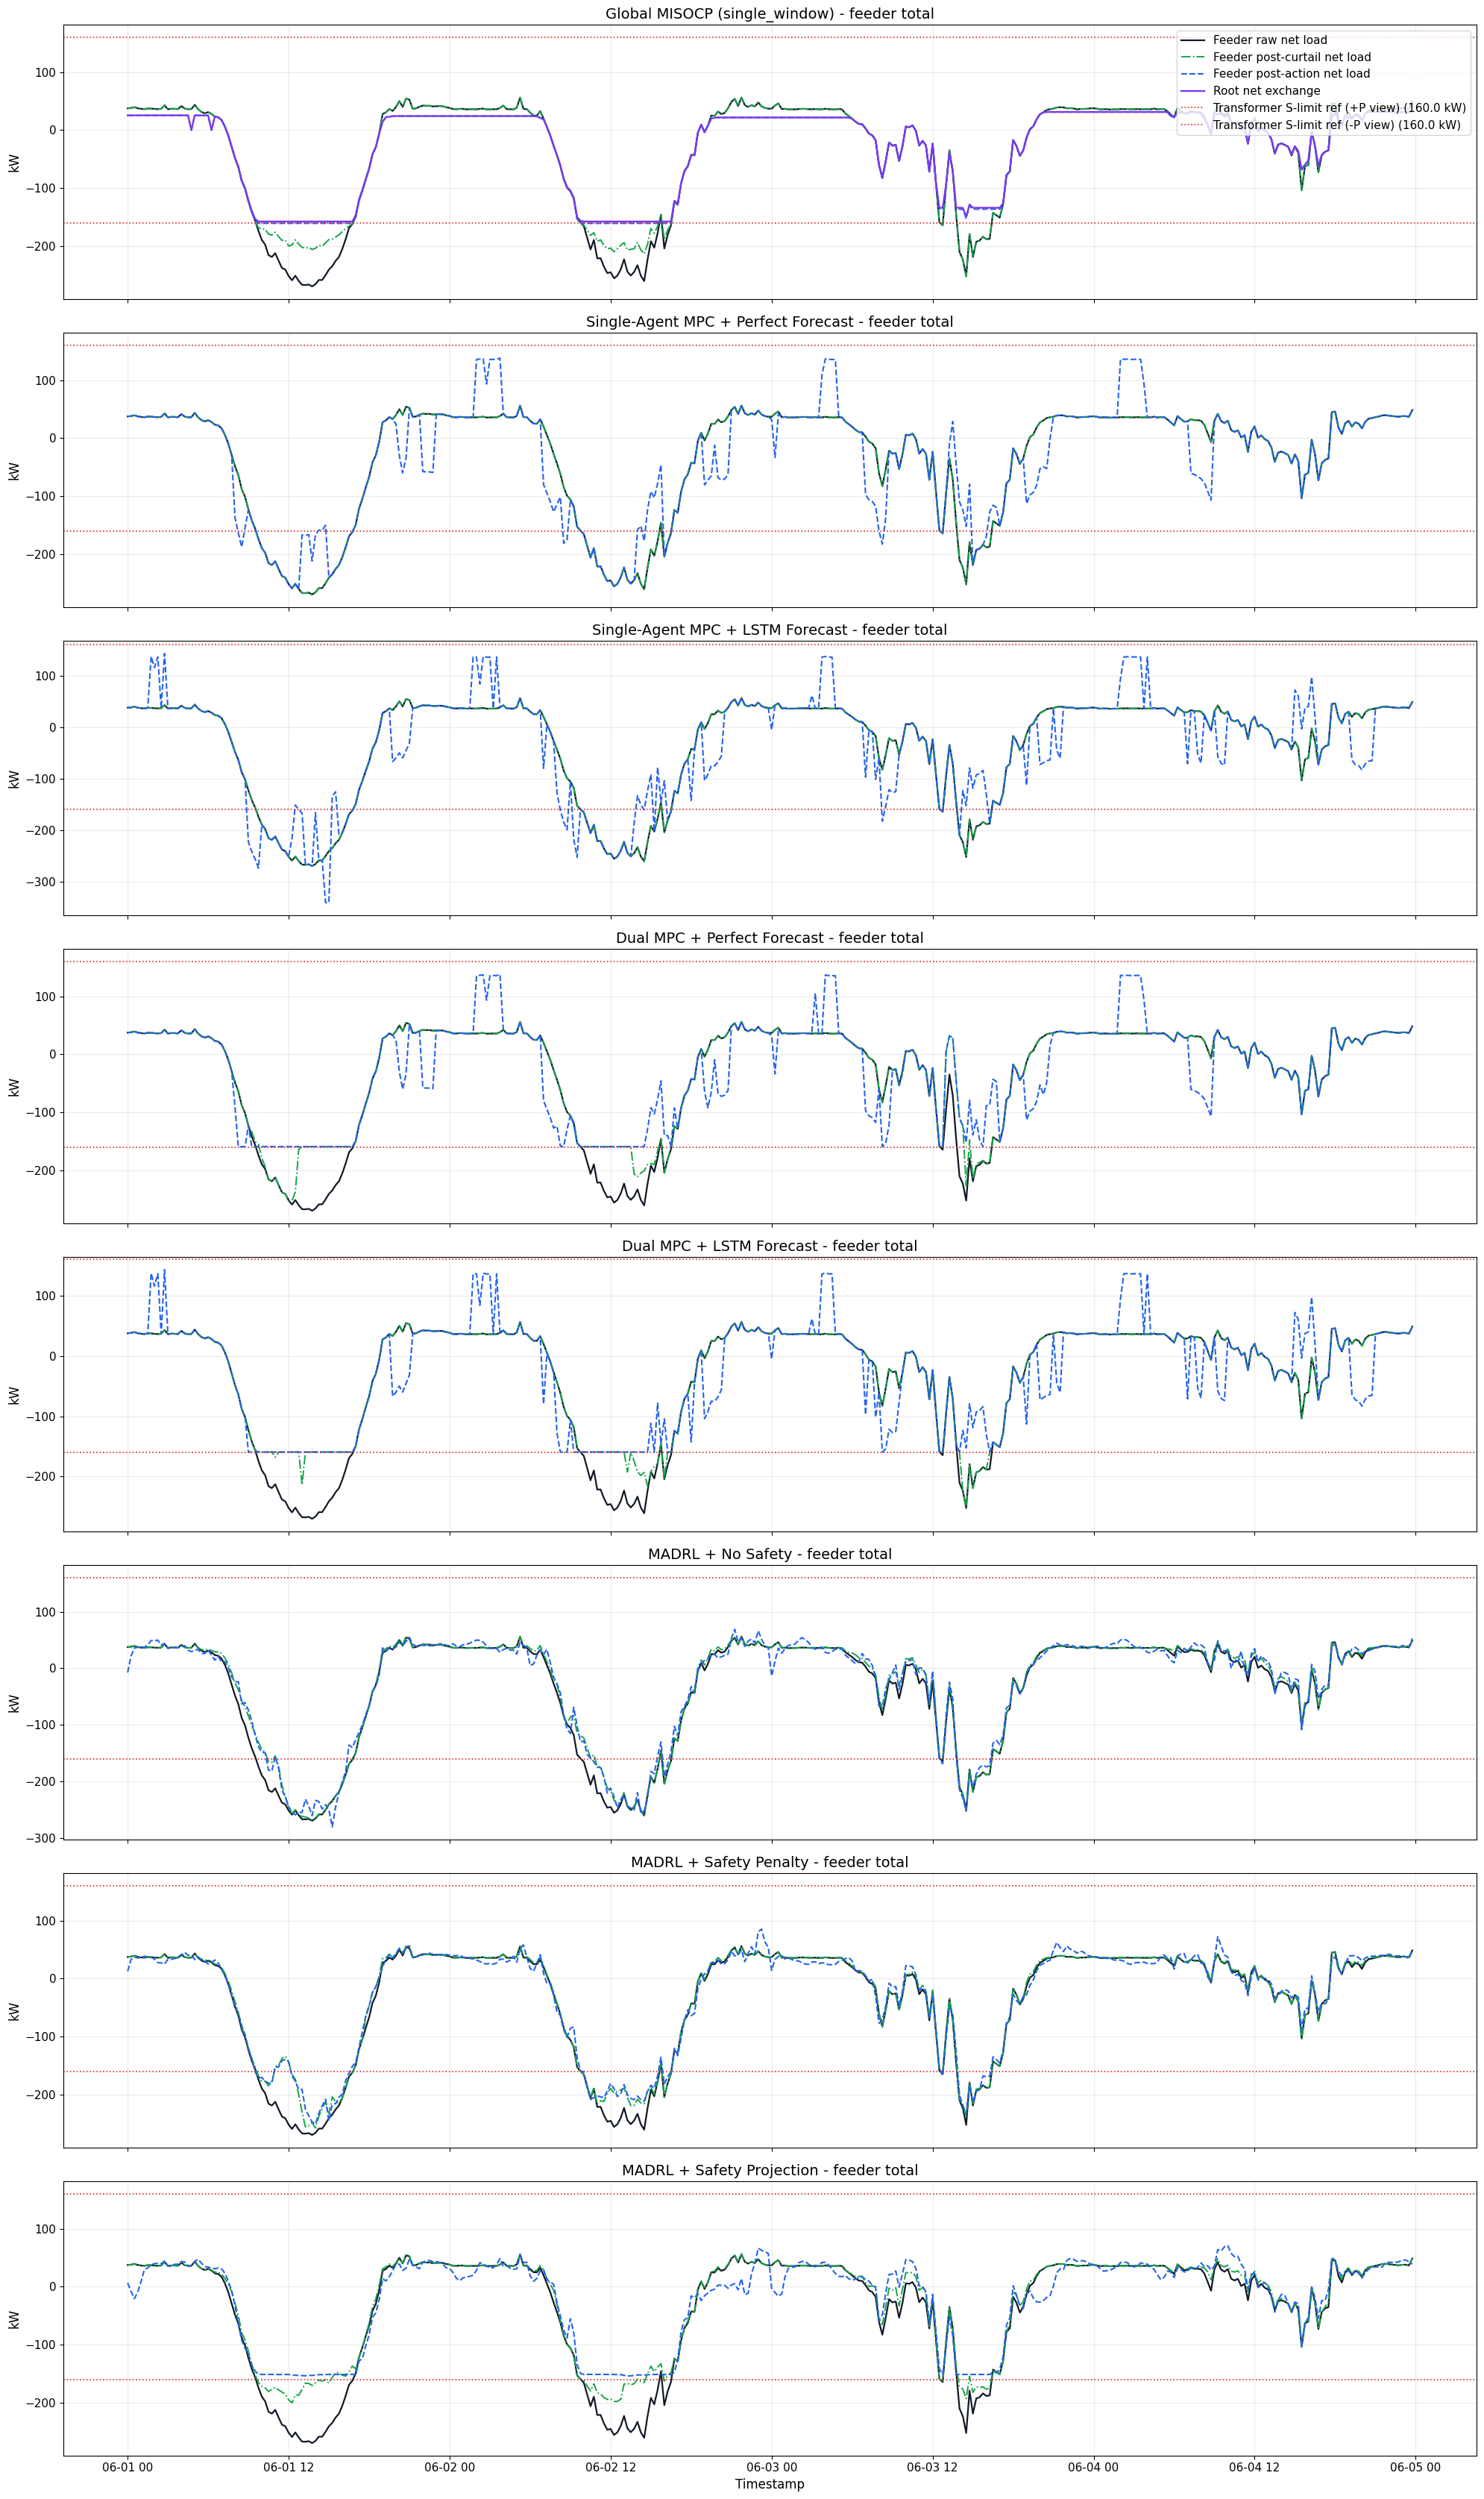

Done: net load
Rendering battery power and SoC...


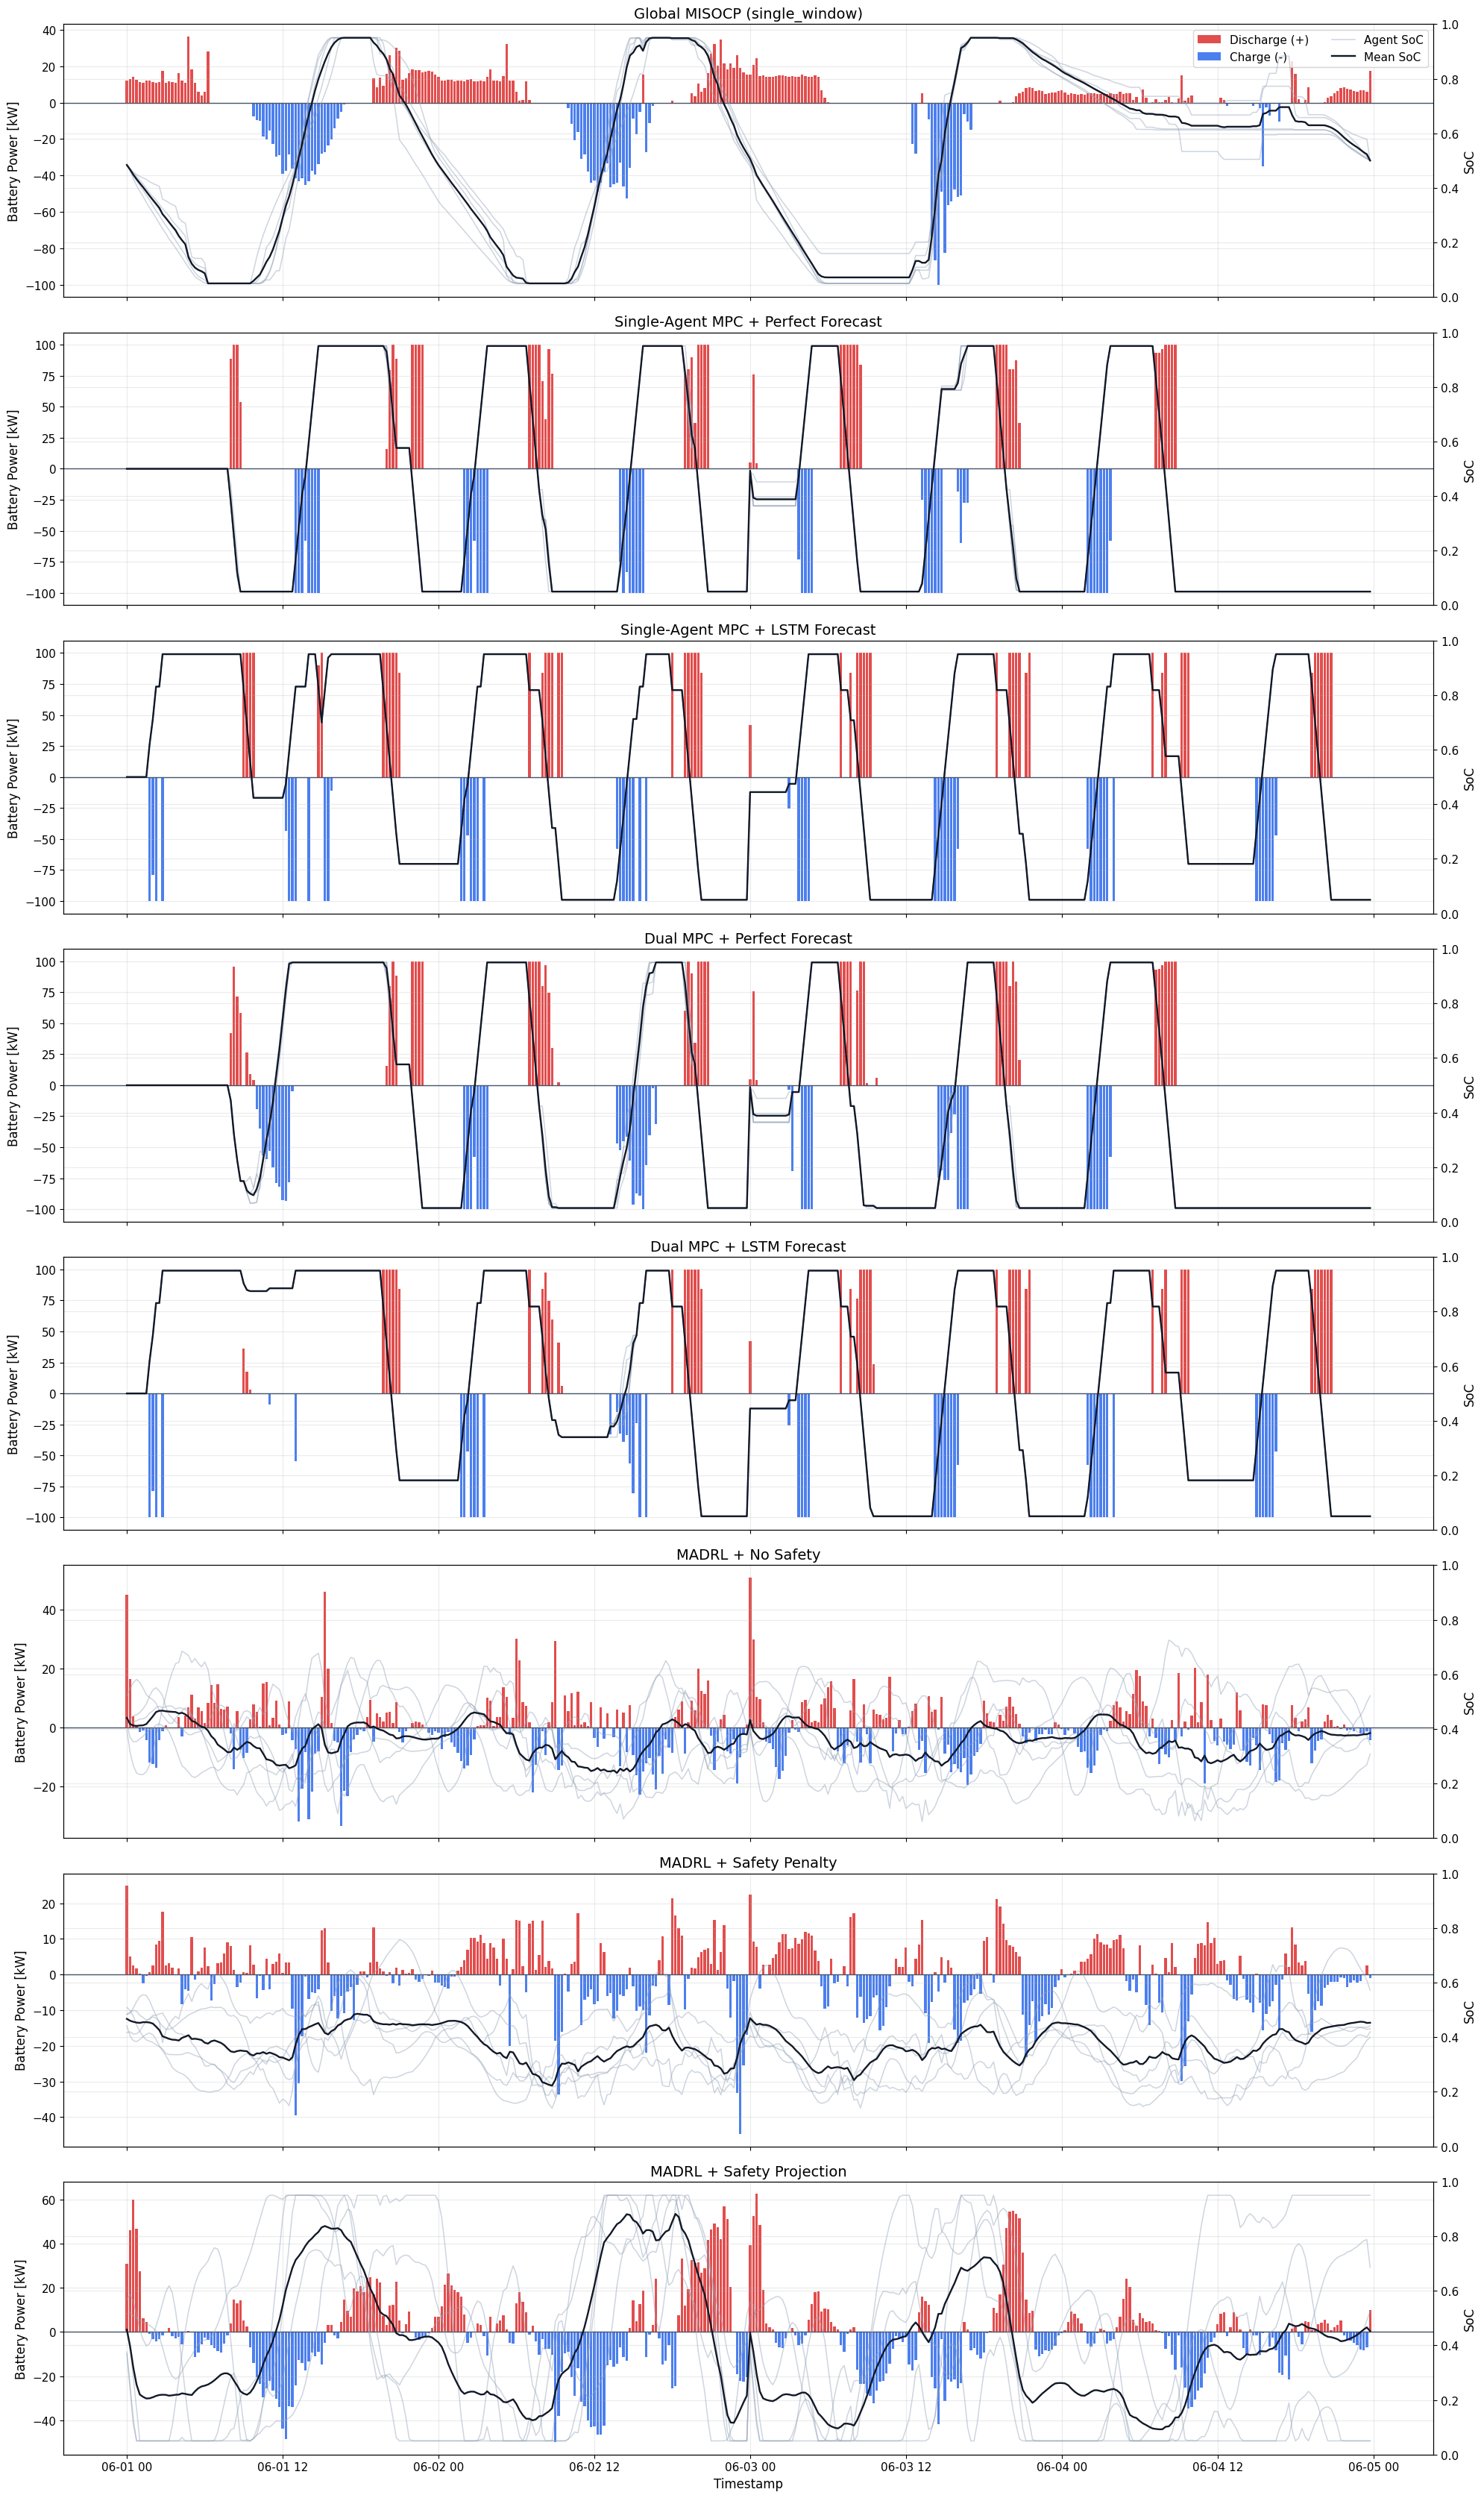

Done: battery power and SoC


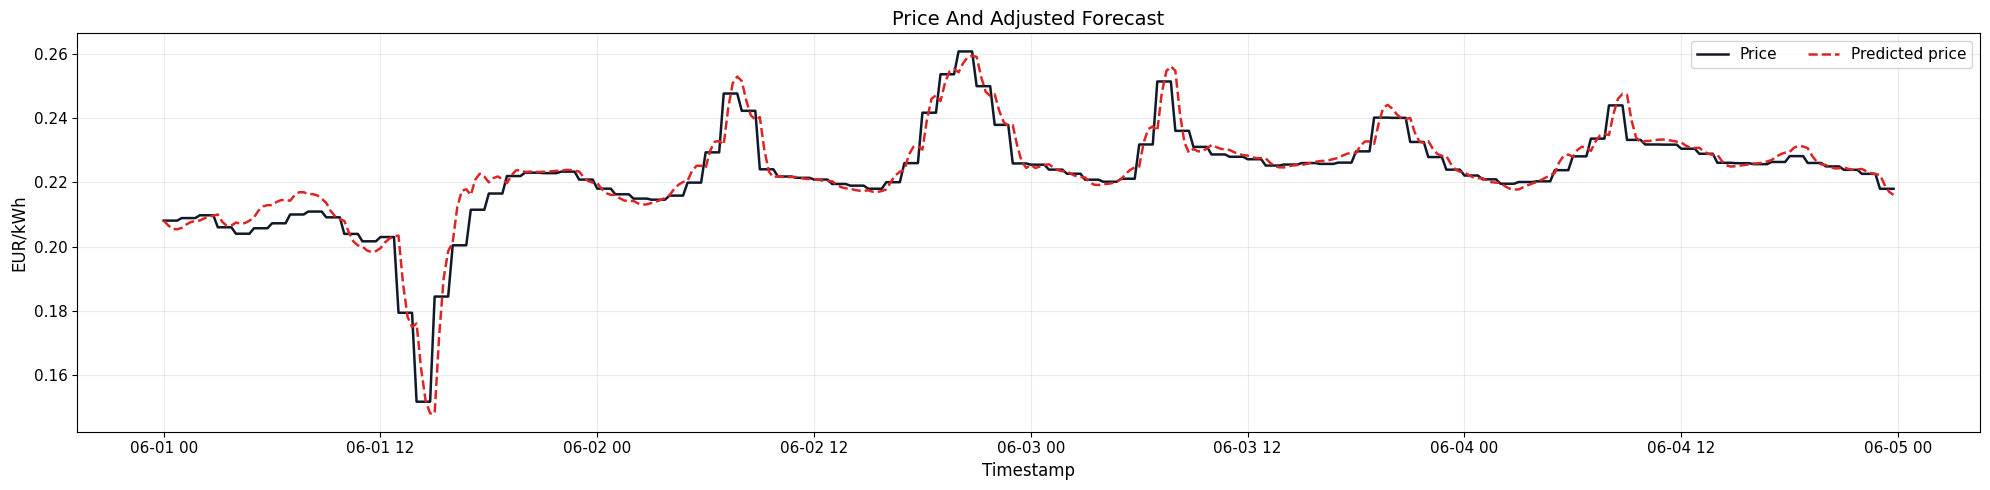

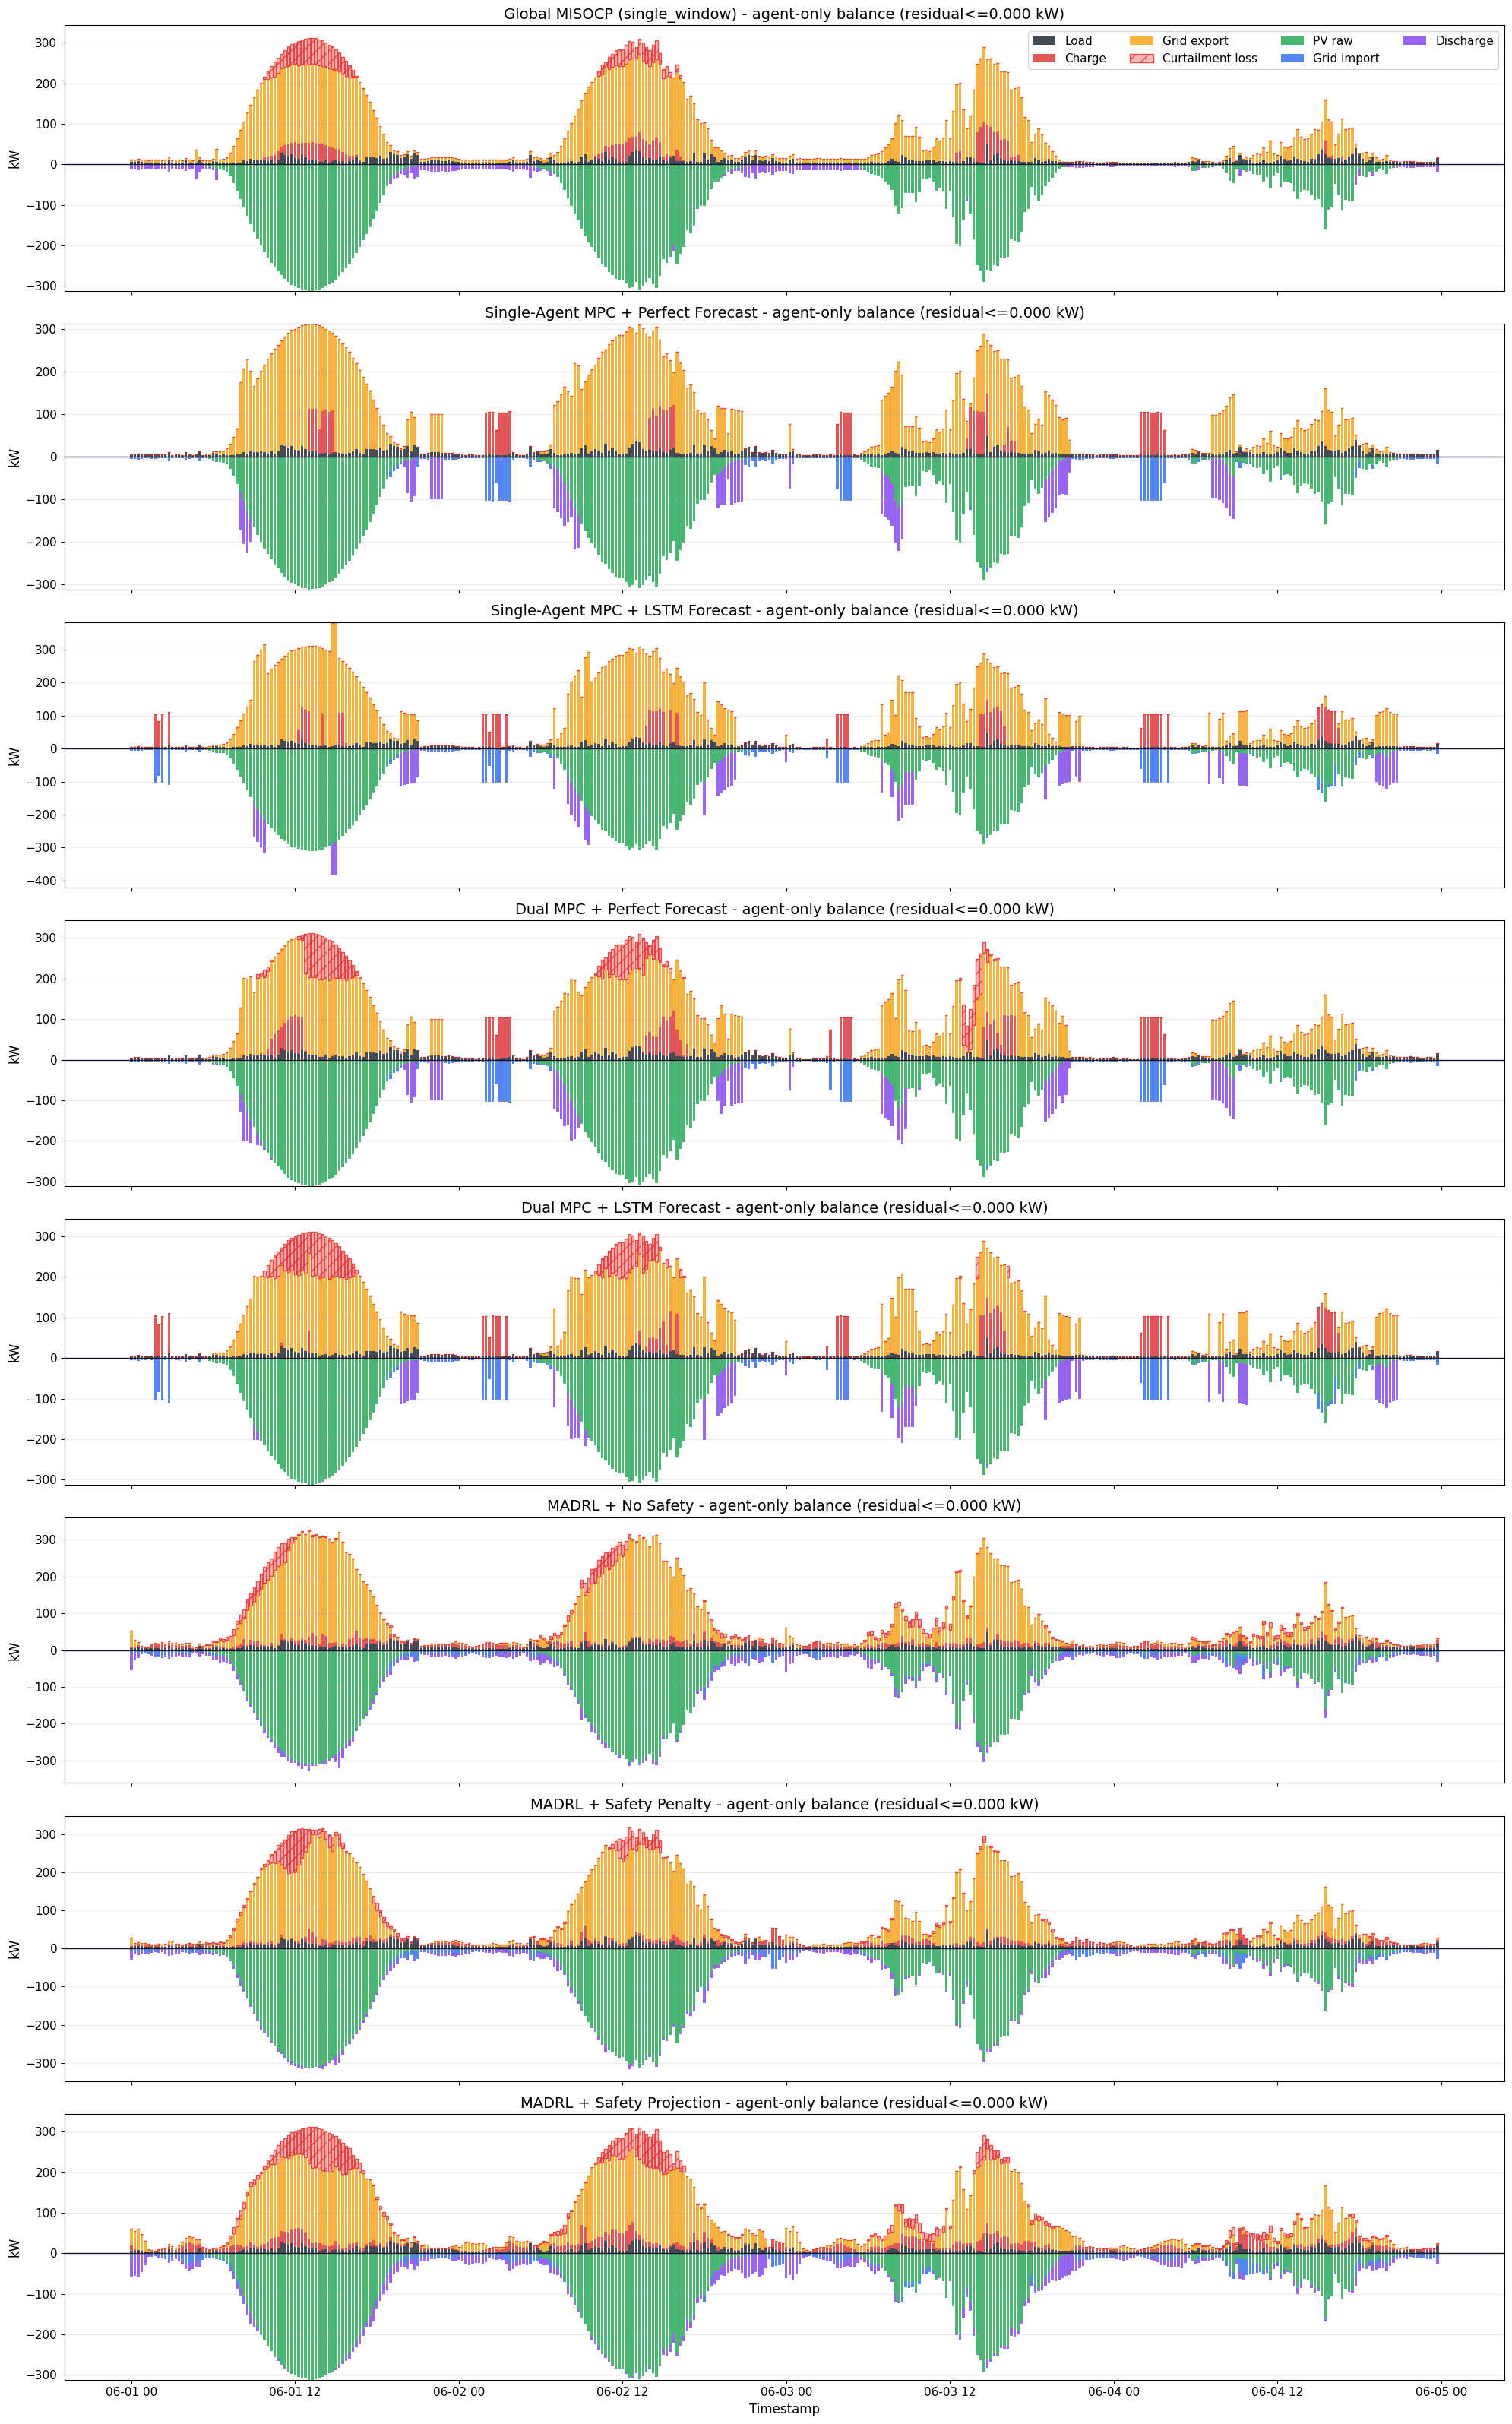

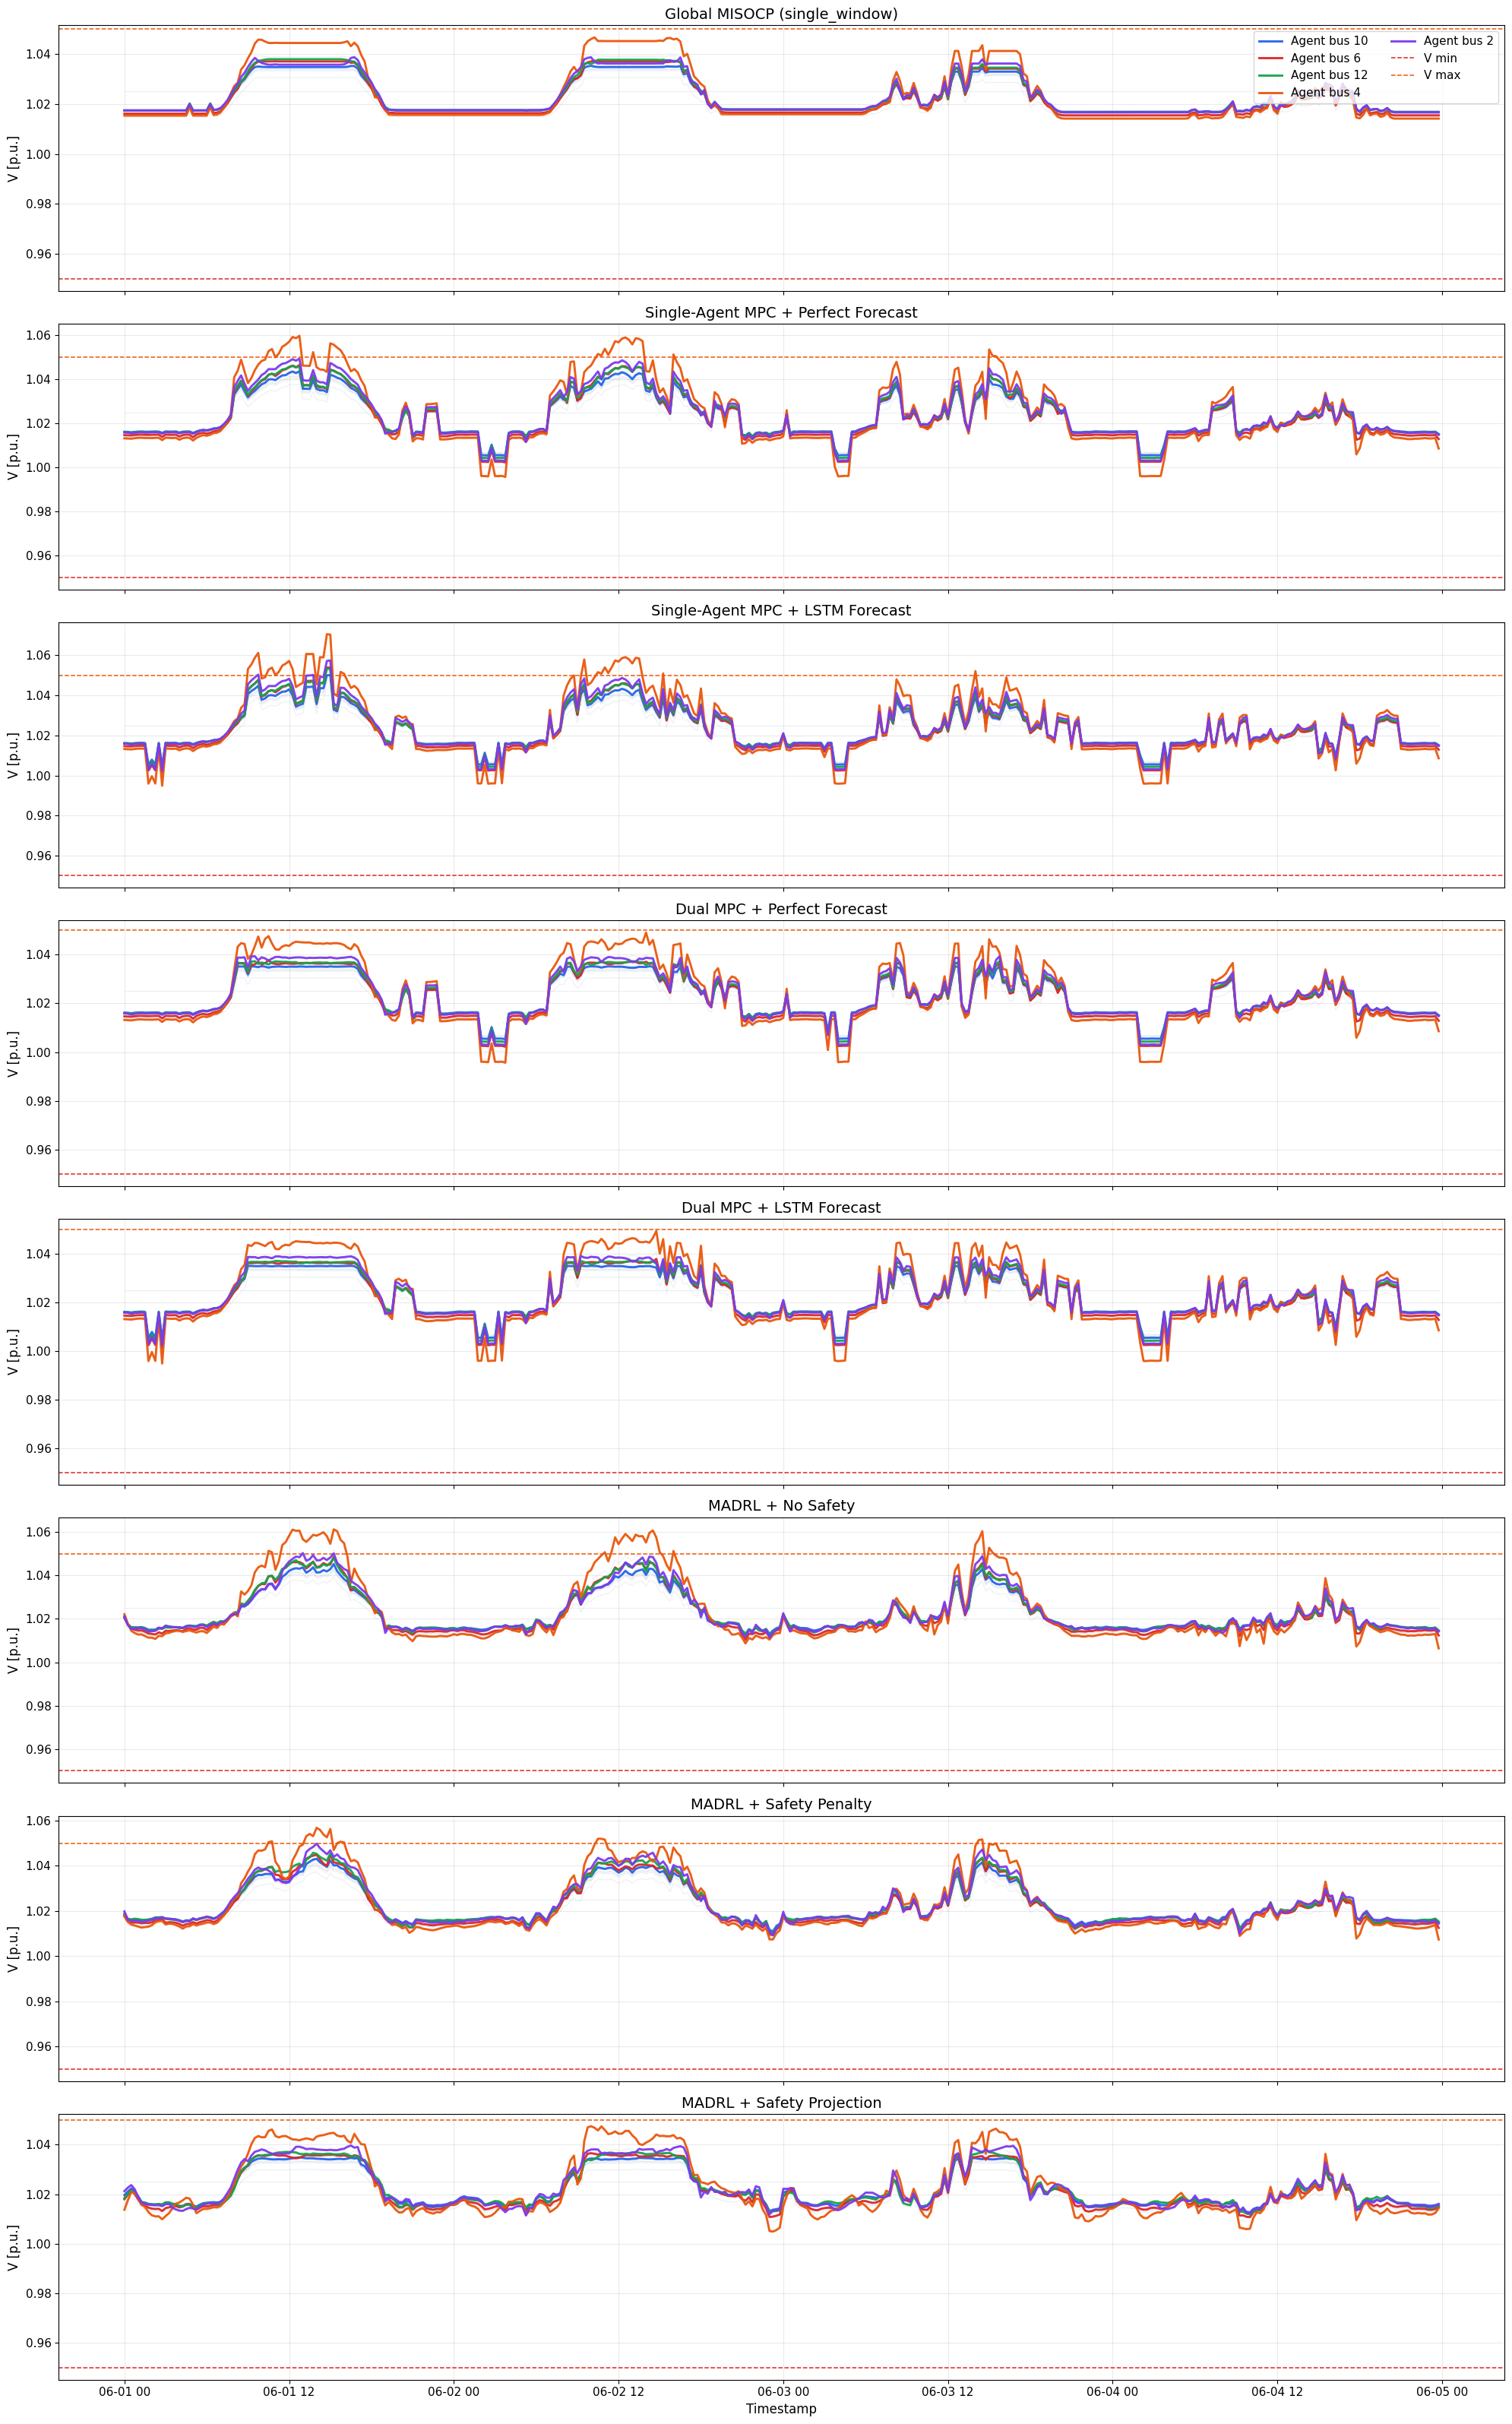

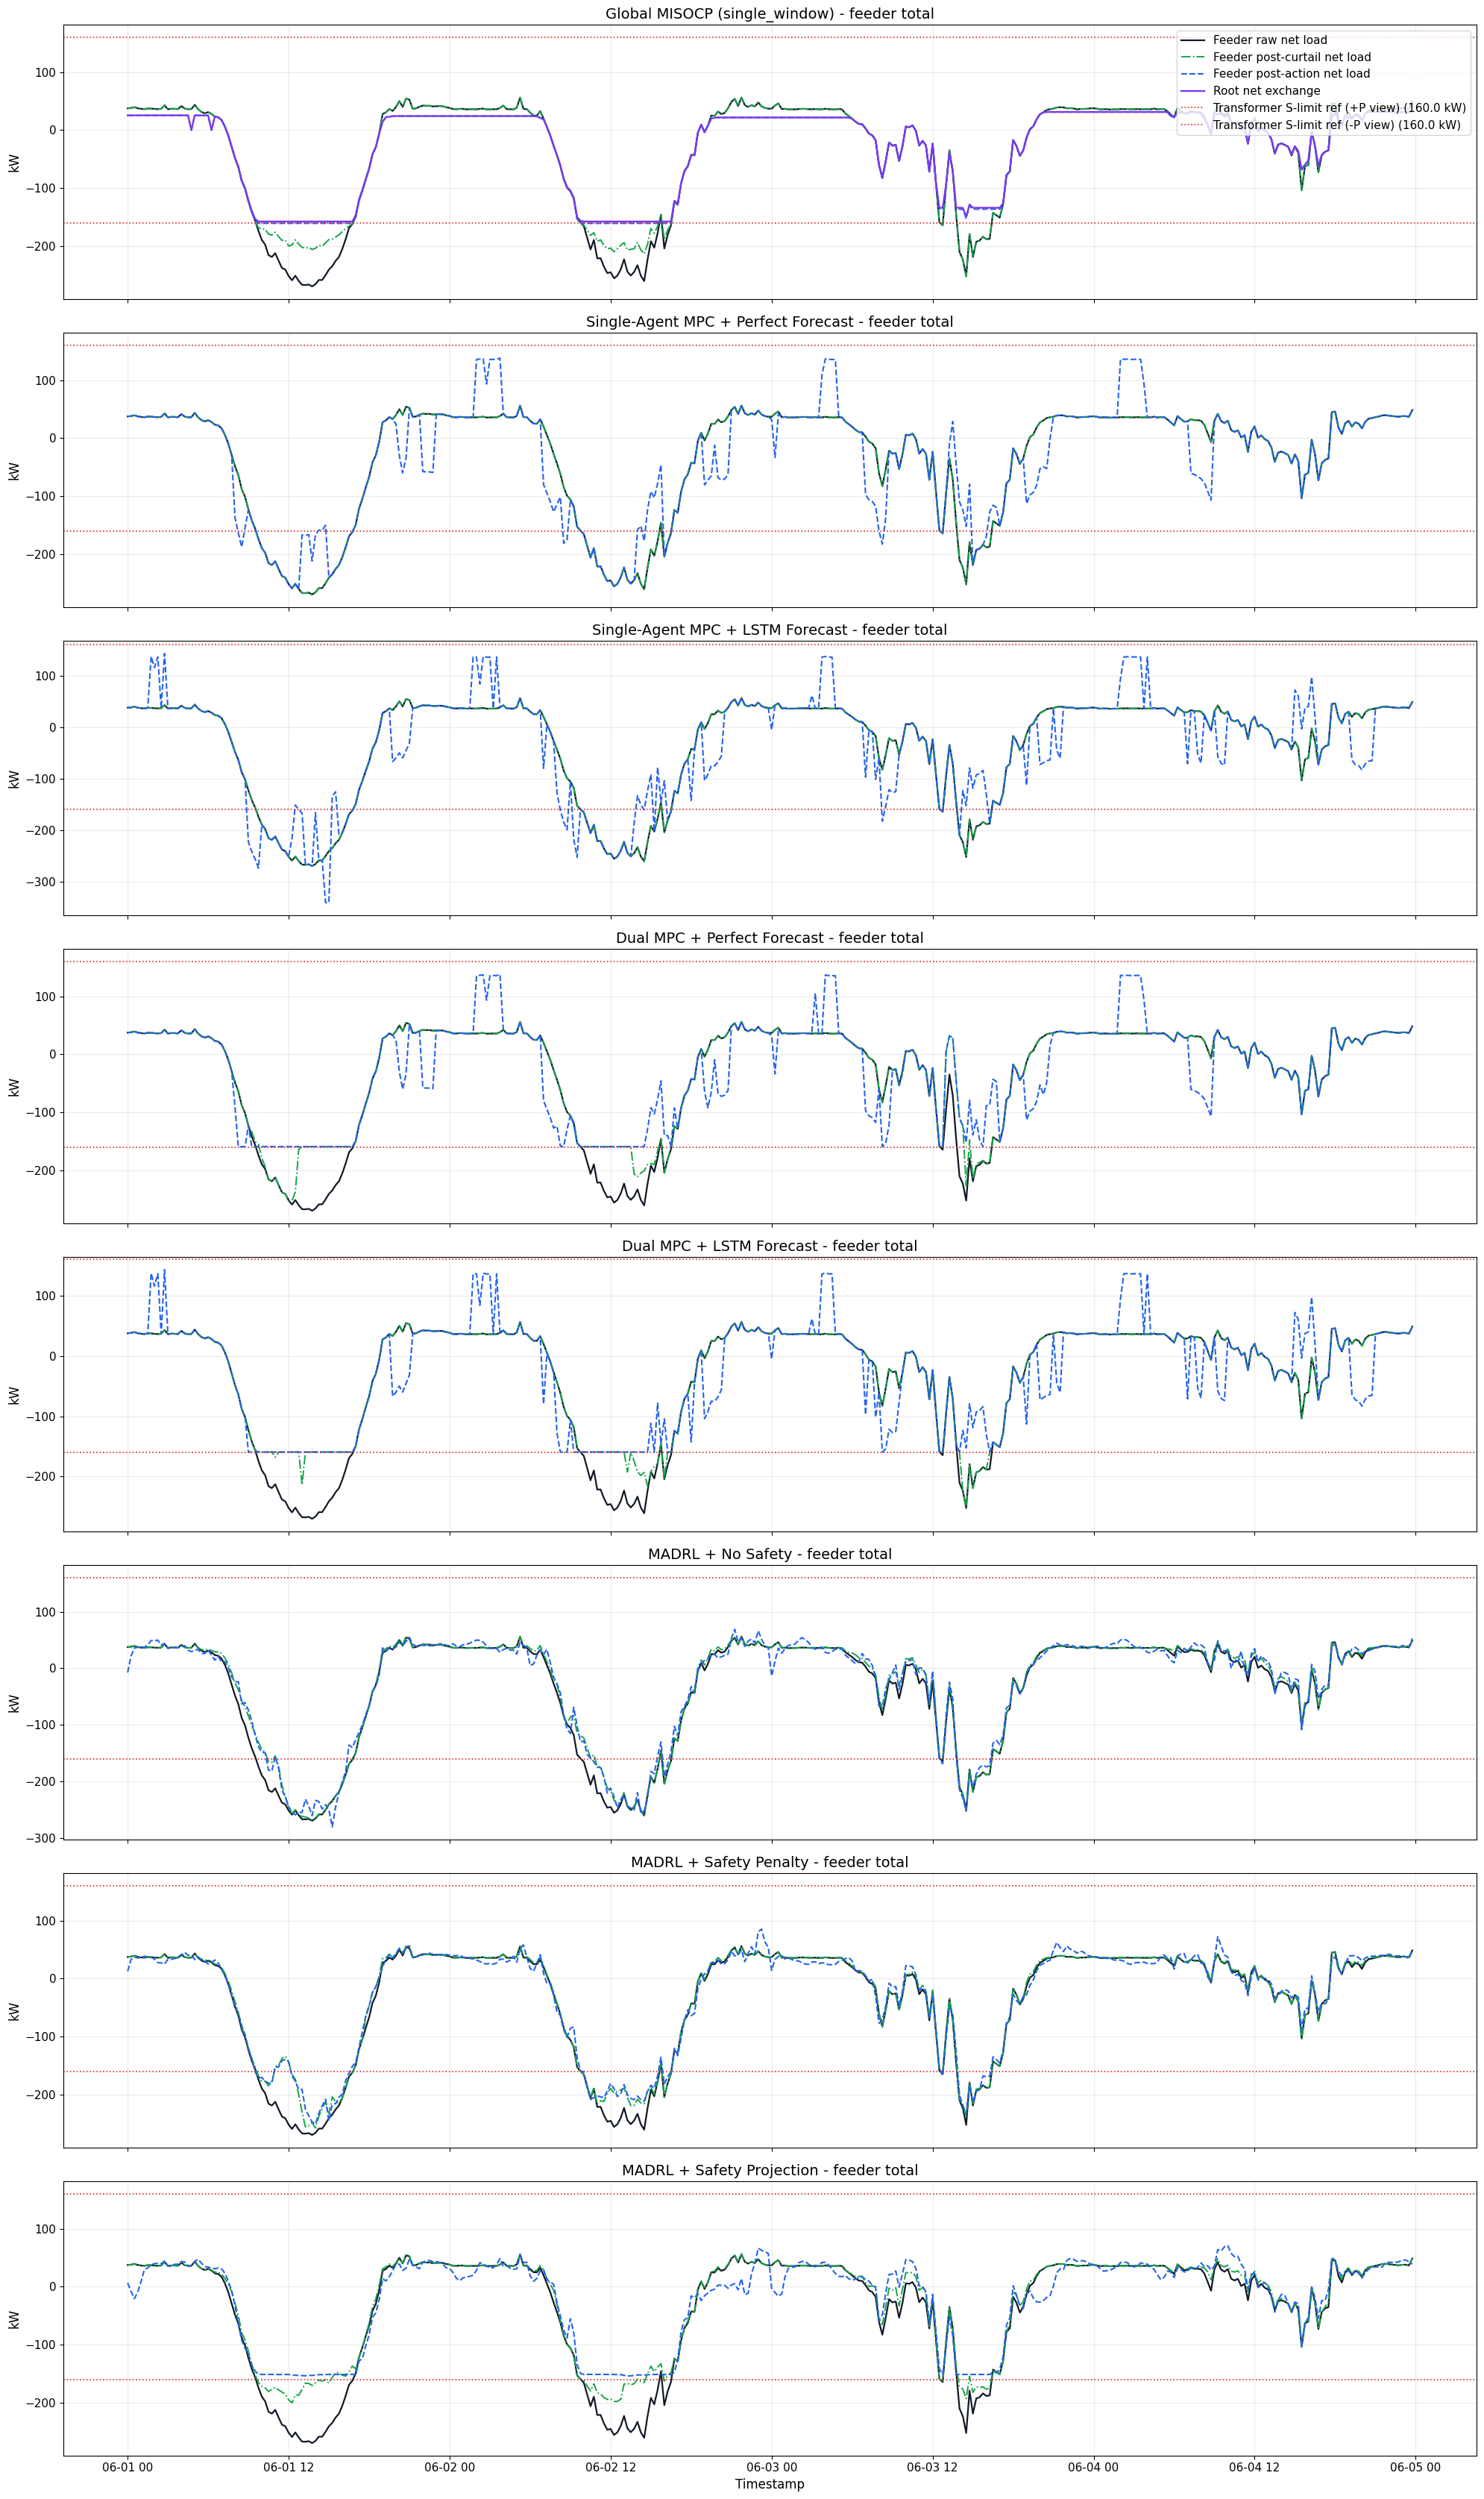

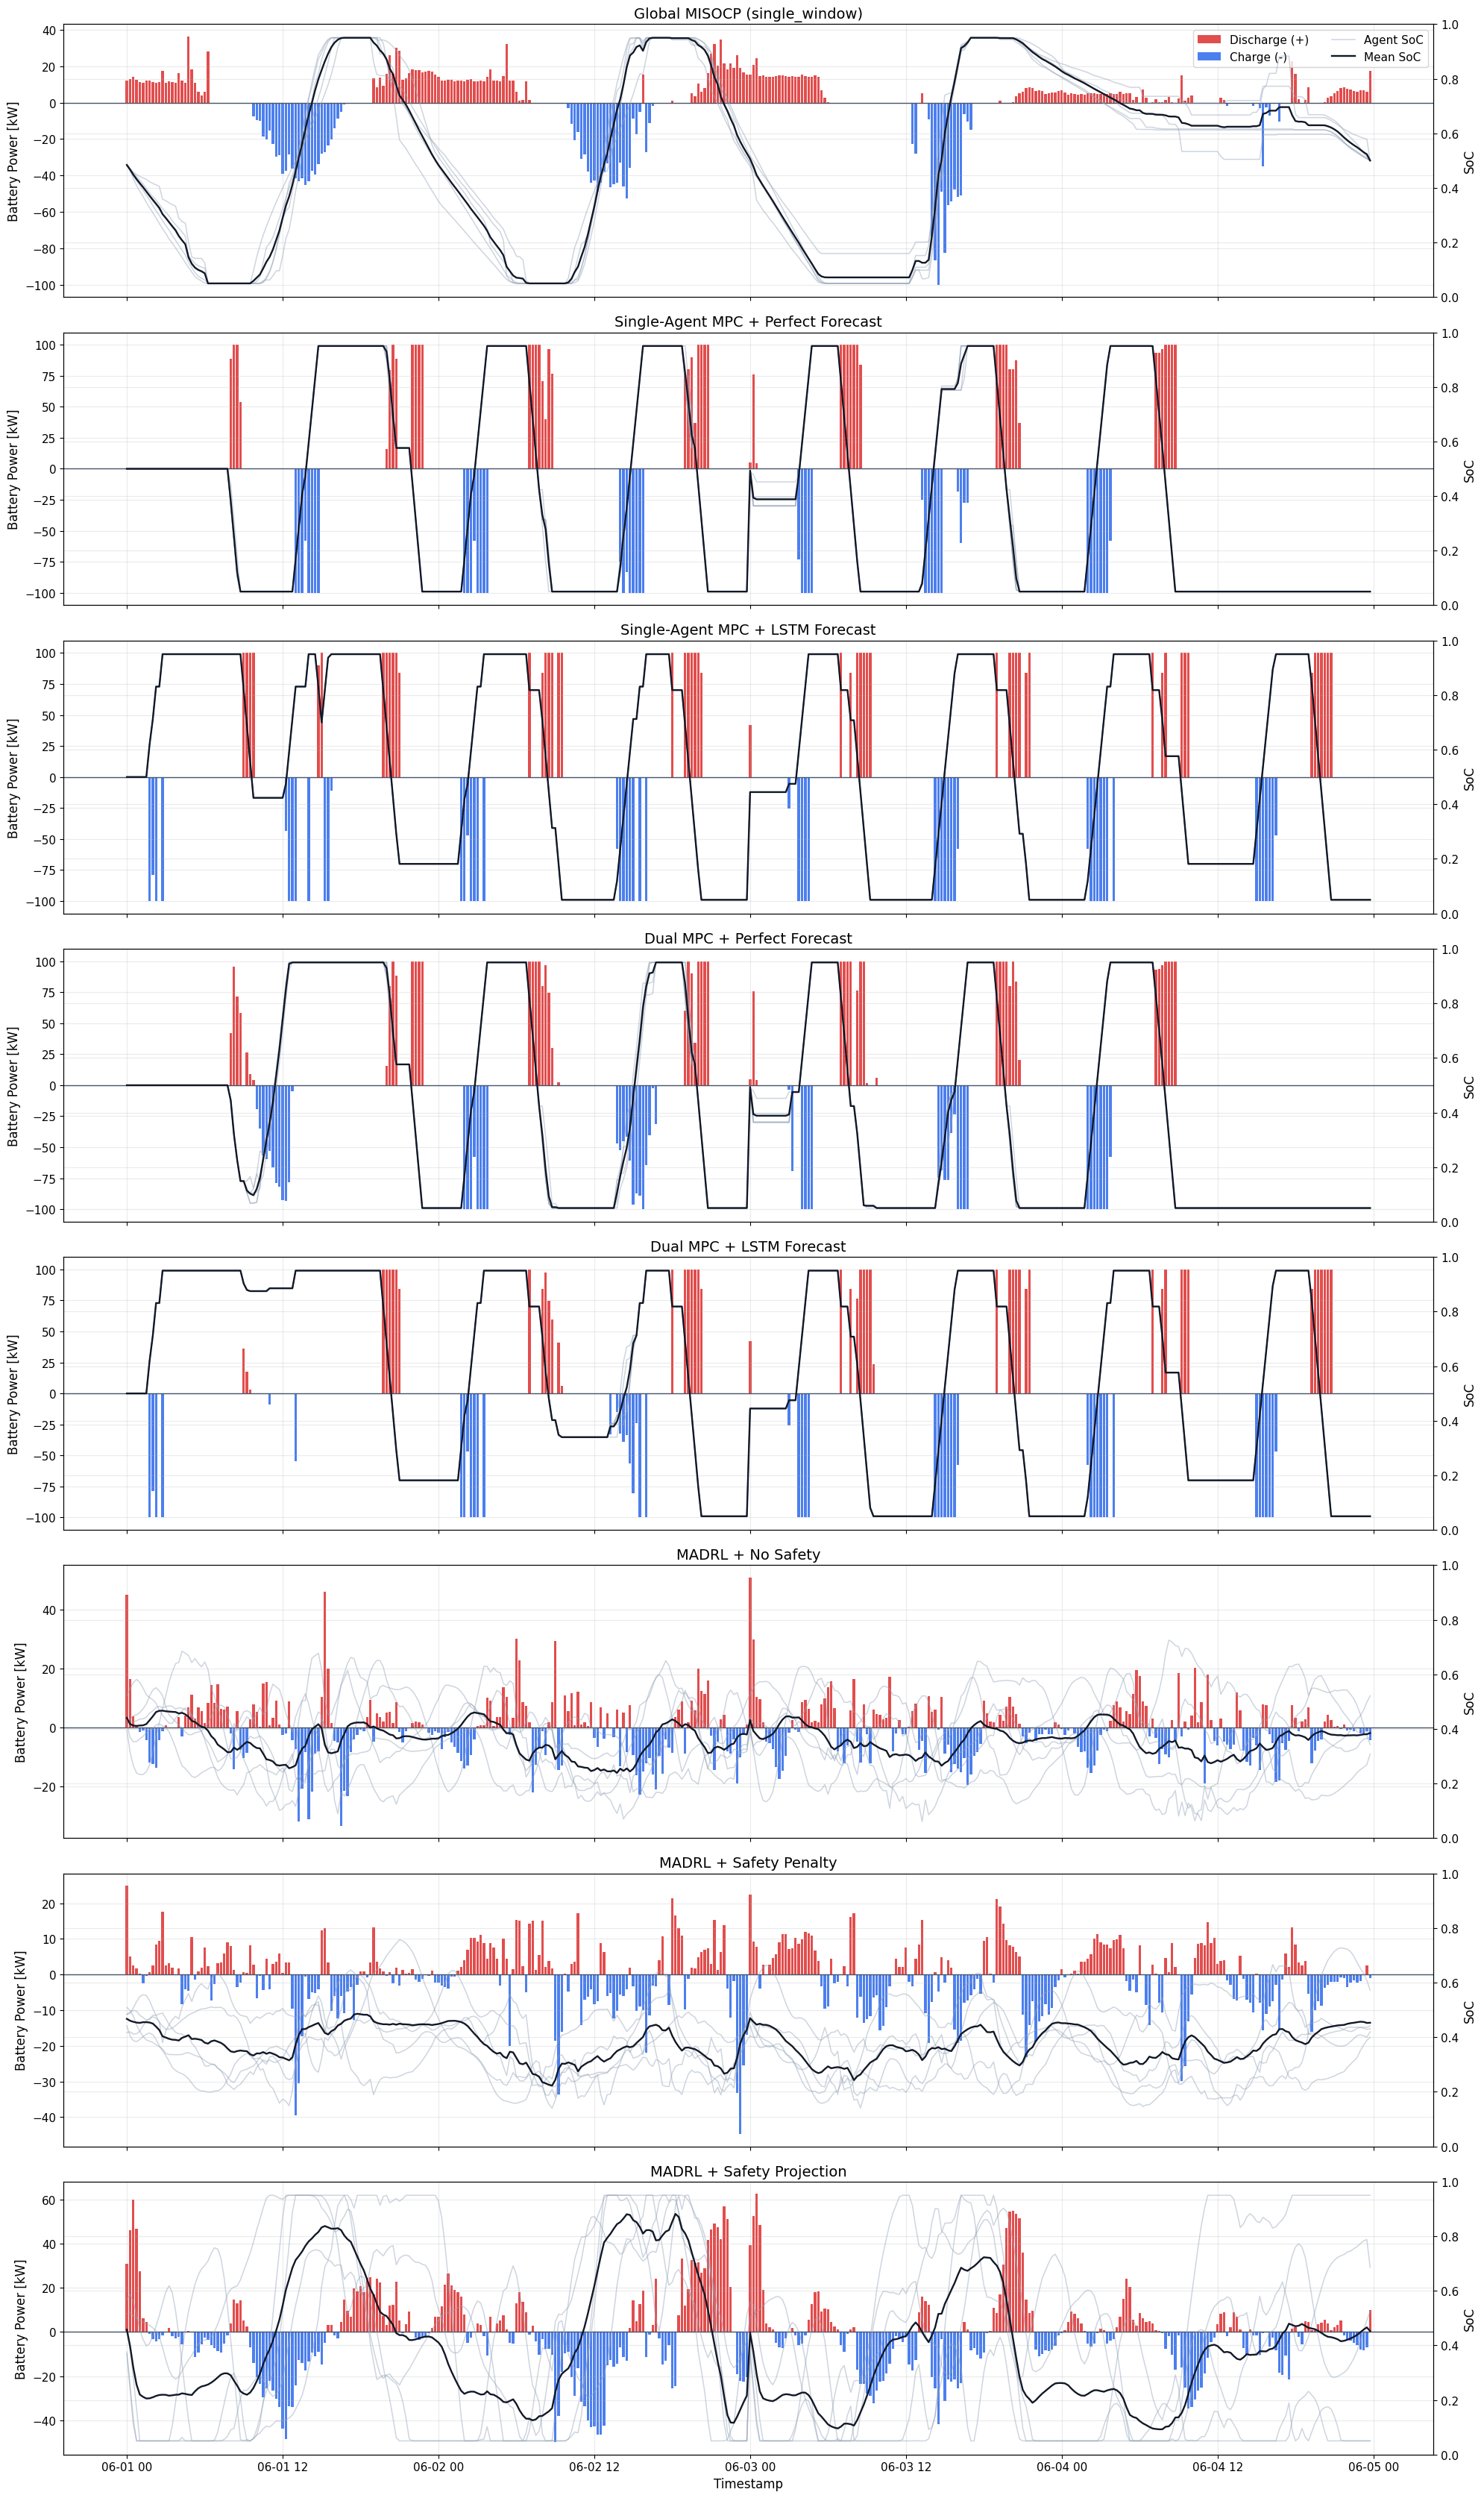

In [ ]:
print("Rendering price and prediction...")
display(plot_price_prediction_comparison(*rollouts))
print("Done: price and prediction")
print("Rendering power balance...")
display(plot_power_balance_comparison(*rollouts))
print("Done: power balance")
print("Rendering voltage profile...")
display(plot_voltage_profile_comparison(*rollouts))
print("Done: voltage profile")
print("Rendering net load...")
display(plot_net_load_comparison(*rollouts))
print("Done: net load")
print("Rendering battery power and SoC...")
display(plot_battery_power_and_soc_comparison(*rollouts))
print("Done: battery power and SoC")
